In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from demo.core.data import (
    SplitConfig,
    prepare_cmapss_split,
)

# 1. Khởi tạo cấu hình cho tập FD002
config = SplitConfig(
    data_path="demo/data/train_FD002.txt",
    train_ratio=0.70,
    observation_cycle_min=130,
    observation_cycle_max=135,
    rare_fault_probability=0.20,
    rare_fault_max_duration=10,
    rare_fault_start_cycle_min=60,
    rare_fault_magnitude_min=0.03,
    rare_fault_magnitude_max=0.10,
    rare_fault_types=("plateau", "drop", "drift"),
    test_fraction_min=0.10,
    test_fraction_max=0.30,
    random_seed=42,
)

# 2. Nạp dữ liệu
data = prepare_cmapss_split(config)
print("Dữ liệu đã được nạp thành công!")
print(f"- Số máy Train: {len(data['train_ids'])}")
print(f"- Số máy Test:  {len(data['test_ids'])}")

Dữ liệu đã được nạp thành công!
- Số máy Train: 182
- Số máy Test:  78


Tìm thấy 43 động cơ có tiêm lỗi hiếm trong tập Train.


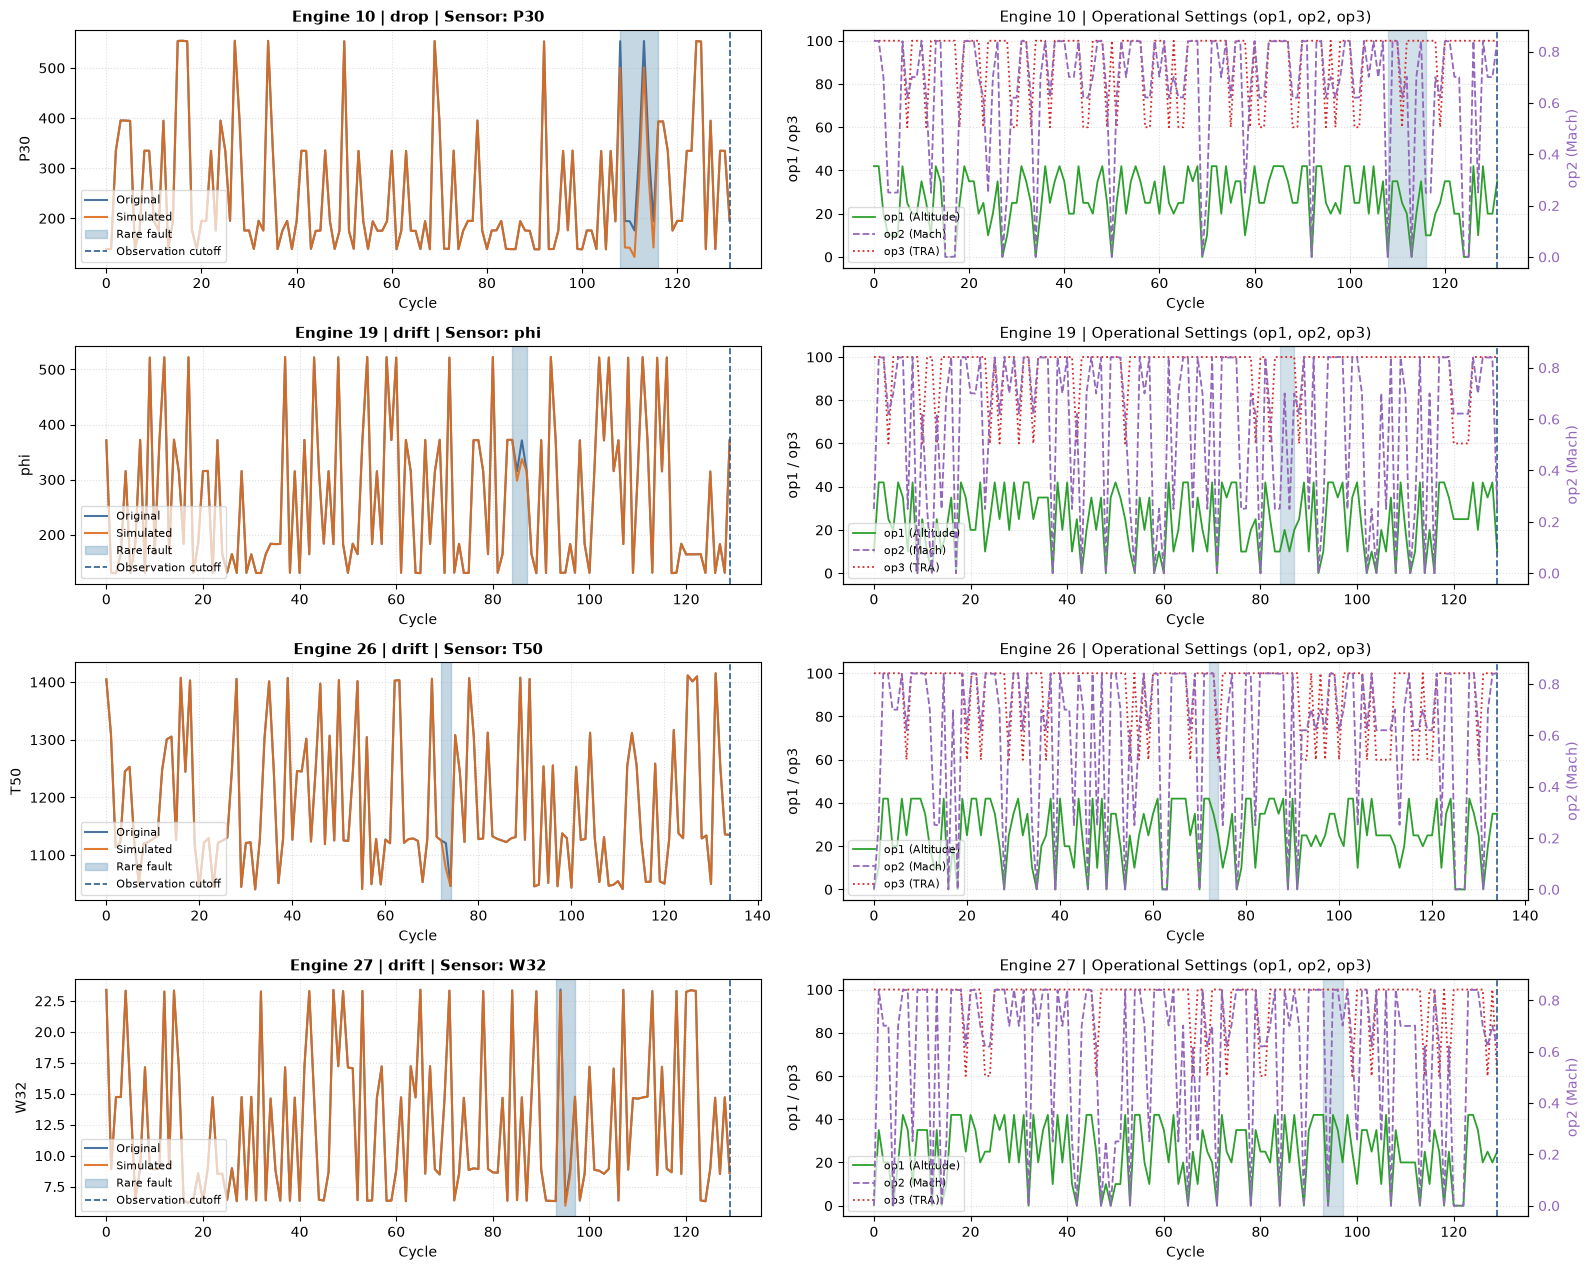

In [3]:
# Lọc tất cả các động cơ có tiêm lỗi bất thường (Rare fault)
fault_engines = [
    eid for eid in data["train_ids"]
    if data["train_metadata"][eid]["has_rare_fault"]
]

print(f"Tìm thấy {len(fault_engines)} động cơ có tiêm lỗi hiếm trong tập Train.")

# Vẽ biểu đồ: Cột 1 là Tín hiệu cảm biến, Cột 2 là 3 biến vận hành (op1, op2, op3)
n_plots = min(4, len(fault_engines))
fig, axes = plt.subplots(n_plots, 2, figsize=(16, 3.2 * n_plots), dpi=100)
if n_plots == 1:
    axes = [axes]

for i, eid in enumerate(fault_engines[:n_plots]):
    meta = data["train_metadata"][eid]
    s_idx = meta["fault_sensor_index"]
    s_name = meta["fault_sensor"]
    f_type = meta["fault_type"]
    start, end = meta["fault_start"], meta["fault_end"]
    cutoff = meta["observed_cycles"]
    
    # 1. Tín hiệu cảm biến (Gốc vs Mô phỏng có tiêm lỗi)
    orig_signal = data["engine_data"][eid][:cutoff, s_idx]
    sim_signal = data["train_data"][eid][:, s_idx]
    
    # 2. Dữ liệu 3 biến điều kiện vận hành (op1, op2, op3)
    op_signal = data["train_op_data"][eid]
    
    # --- CỘT 1: BIỂU ĐỒ CẢM BIẾN ---
    ax_sensor = axes[i][0]
    ax_sensor.plot(orig_signal, label="Original", color="#2b5c8f", alpha=0.85, linewidth=1.5)
    ax_sensor.plot(sim_signal, label="Simulated", color="#e06c1b", alpha=0.9, linewidth=1.5)
    ax_sensor.axvspan(start, end, color="#7ca8c2", alpha=0.45, label="Rare fault")
    ax_sensor.axvline(x=cutoff - 1, color="#2b5c8f", linestyle="--", linewidth=1.2, label="Observation cutoff")
    
    ax_sensor.set_title(f"Engine {eid} | {f_type} | Sensor: {s_name}", fontsize=11, fontweight="bold")
    ax_sensor.set_xlabel("Cycle", fontsize=10)
    ax_sensor.set_ylabel(s_name, fontsize=10)
    ax_sensor.legend(loc="lower left", fontsize=8, framealpha=0.7)
    ax_sensor.grid(True, linestyle=":", alpha=0.4)
    
    # --- CỘT 2: BIỂU ĐỒ 3 BIẾN VẬN HÀNH (op1, op2, op3) ---
    ax_op = axes[i][1]
    l1 = ax_op.plot(op_signal[:, 0], label="op1 (Altitude)", color="#2ca02c", linewidth=1.3)
    l3 = ax_op.plot(op_signal[:, 2], label="op3 (TRA)", color="#d62728", linewidth=1.3, linestyle=":")
    ax_op.set_ylabel("op1 / op3", fontsize=10)
    ax_op.set_xlabel("Cycle", fontsize=10)
    ax_op.grid(True, linestyle=":", alpha=0.4)
    
    # Trục phụ y2 cho op2 (Mach: 0 - 0.84)
    ax_op2 = ax_op.twinx()
    l2 = ax_op2.plot(op_signal[:, 1], label="op2 (Mach)", color="#9467bd", linewidth=1.3, linestyle="--")
    ax_op2.set_ylabel("op2 (Mach)", fontsize=10, color="#9467bd")
    ax_op2.tick_params(axis="y", labelcolor="#9467bd")
    
    # Đánh dấu vùng rare fault trên đồ thị op
    ax_op.axvspan(start, end, color="#7ca8c2", alpha=0.35, label="Rare fault")
    ax_op.axvline(x=cutoff - 1, color="#2b5c8f", linestyle="--", linewidth=1.2)
    
    # Gộp legend 3 đường op
    lines = l1 + l2 + l3
    labels = [l.get_label() for l in lines]
    ax_op.legend(lines, labels, loc="lower left", fontsize=8, framealpha=0.7)
    ax_op.set_title(f"Engine {eid} | Operational Settings (op1, op2, op3)", fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Kiểm tra bảng metadata chi tiết các máy có lỗi
print(f"{'ID':>4} | {'Quan sát':>8} | {'Tổng cycle':>10} | {'RUL thật':>8} | {'Loại lỗi':>10} | {'Sensor':>10} | {'Khoảng cycle':>12}")
print("-" * 80)
for eid in fault_engines[:8]:
    m = data["train_metadata"][eid]
    print(f"{eid:>4} | {m['observed_cycles']:>8} | {m['total_cycles']:>10} | {m['actual_rul_at_stop']:>8} | {m['fault_type']:>10} | {m['fault_sensor']:>10} | {m['fault_start']}-{m['fault_end']:>8}")